# RAG Evaluation Lab: which design choices actually matter?

## Background

I built a small question-answering system over biomedical abstracts and ran a
proper experiment on it: a 2x2x2 factorial design testing chunk size, top-k,
and query rewriting. This notebook walks through the whole thing: the corpus,
the test questions, the analysis plan I wrote before seeing any results, the
statistics, and what I concluded.

The question I wanted answered: when you build a retrieval-augmented system,
which of these three knobs is worth turning?

## Setup (the data)

- **Corpus:** 579 recent PubMed abstracts, fetched via Entrez (no API key)
  with four fixed queries: type 2 diabetes treatment (149), hypertension
  management (139), asthma inhaler therapy (145), migraine prevention (146).
  `data/corpus.jsonl`, built by `data/build_corpus.py`.
- **Test questions:** 40 questions, 10 per topic, drafted by Gemini from a
  source passage and kept only if a verbatim evidence quote supported the
  answer (56 drafted, 52 passed verification). `data/questions.json`.
- **Query rewrites:** one Gemini rewrite per question, generated once and
  reused across conditions so rewriting is a clean factor.
  `data/rewrites.json`.
- **Generation labels:** claim-level faithfulness judgments from an
  independent judge model, cached in `data/judge.json`.

The retrieval experiment reruns live in this notebook with a TF-IDF ranker
(no API calls). The generation and judging were done once; their labels are
committed. Everything needed is in `data/` and `src/`, so the notebook reruns
from the repo. One implementation note: `src/corpus.py` defaults to an old
local path, so the notebook passes the repo-relative path explicitly.

In [1]:
import sys
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
DATA = os.path.join(ROOT, "data")
FIG = os.path.join(ROOT, "figures")
import json
import pandas as pd
import numpy as np
from corpus import load_corpus, build_chunks

docs = load_corpus(os.path.join(DATA, "corpus.jsonl"))
print(f"{len(docs)} abstracts in the corpus")
topics = pd.Series([d["topic_query"] for d in docs]).value_counts()
print(topics.to_string())
lens = [len(d["abstract"].split()) for d in docs]
print(f"\nabstract length: median {int(np.median(lens))} words, range {min(lens)}-{max(lens)}")
print("\nexample title:", docs[0]["title"][:110])


579 abstracts in the corpus
type_2_diabetes_treatment    149
migraine_prevention          146
asthma_inhaler_therapy       145
hypertension_management      139

abstract length: median 257 words, range 41-2604

example title: The causal relationship between diabetes mellitus and hashimoto thyroiditis: A two-sample mendelian randomizat


## Method

### Why a factorial experiment?

I had three design choices to make: how big each text chunk should be, how many
chunks to hand the generator, and whether to rewrite the user's question before
retrieving. A factorial design tests all three at once, and it also tests
whether they interact (for example, maybe rewriting only helps with small
chunks). Every one of the 40 test questions goes through all 8 conditions, so
questions act as their own controls. That is a repeated-measures design, and it
is much more sensitive than testing 8 separate groups of questions.

### Analysis plan (written before running the experiment)

I am writing this down before looking at any results so I cannot cherry-pick
afterwards.

**Factors:** chunk size (150 vs 450 words) x top-k (3 vs 8) x query rewriting
(off vs on). Fully within-subjects; the blocking unit is the question.

**Retrieval metrics** (all 40 questions x 8 conditions): recall@k, MRR, nDCG@k.
The relevance judgment is the single chunk containing the passage the question
was drawn from. Binary relevance, so recall@k is 0/1 per question.

**Generation metric** (pre-registered random subset of 10 questions x 8
conditions, seed 20261002): claim-level faithfulness. An independent judge model
breaks each answer into atomic claims and marks each supported / contradicted /
unverifiable against the retrieved passages. Faithfulness = supported claims /
total claims. Abstentions ("not stated in the provided context") make no factual
claim and are excluded from faithfulness, counted separately.

**Statistics:** for each metric, a repeated-measures ANOVA with the three
factors (questions as blocks), reporting F, p, and partial eta-squared. Then
three planned paired contrasts (one per factor, marginal means paired by
question) with the mean difference, a 95% CI, and Cohen's dz. No other tests.
If nothing is significant, I will say so and talk about effect sizes and ceiling
effects instead of hunting for a story.

In [2]:
# Test questions: drafted by the LLM, then verified against the source passage
qdata = json.load(open(os.path.join(DATA, "questions.json")))
print("meta:", qdata["meta"])
qs = qdata["questions"]
print(f"\n{len(qs)} questions, {len(set(q['topic'] for q in qs))} topics")
for q in qs[:3]:
    print("\n---", q["question_id"], q["topic"])
    print("Q:", q["question"])
    print("A:", q["reference_answer"][:160])


meta: {'seed': 20261002, 'n_drafted': 56, 'n_verified_kept': 52, 'n_final': 40}

40 questions, 4 topics

--- q01 asthma_inhaler_therapy
Q: Why was DSPE-PEG chosen among various PEGylated lipids for the liposomal formulation?
A: DSPE-PEG was selected because its amine function maximizes indacaterol encapsulation through amine-phosphate interactions, and its 18-carbon chain provides supe

--- q02 asthma_inhaler_therapy
Q: What benefits do pulmonary rehabilitation programs offer when combined with structured exercise, maintenance interventions, and telemonitoring?
A: When combined with structured exercise programs, maintenance interventions, and telemonitoring systems, pulmonary rehabilitation can significantly improve a pat

--- q03 asthma_inhaler_therapy
Q: What was the ratio of mometasone to magnesium stearate maintained in all of the evaluated formulations?
A: In all of the tested formulations, the ratio of mometasone to magnesium stearate (MgSt) was kept at 99:1.


Each question survived a strict check: the draft had to include a verbatim
quote from its source passage, and the answer had to share content words with
that quote. 56 were drafted, 52 passed, and I kept a balanced 40 (10 per
topic). The verification matters because a test question whose answer is not
really in the passage would punish the system unfairly.

## Results

In [3]:
# Retrieval experiment, re-run live (no API calls: TF-IDF ranking only)
import itertools
from retrieval import Retriever, retrieval_metrics

chunk_sets = {
    "small": build_chunks(docs, 150, 30, prefix="s"),
    "large": build_chunks(docs, 450, 60, prefix="l"),
}
retrievers = {name: Retriever(ch) for name, ch in chunk_sets.items()}
rewrites = json.load(open(os.path.join(DATA, "rewrites.json")))
q_by_id = {q["question_id"]: q for q in qs}
small_by_id = {c["chunk_id"]: c for c in chunk_sets["small"]}

def norm(s):
    import re
    return re.sub(r"\s+", " ", s.strip().lower())

def large_for_small(sc):
    head = norm(sc["text"])[:60]
    for c in chunk_sets["large"]:
        if c["doc_id"] == sc["doc_id"] and head in norm(c["text"]):
            return c["chunk_id"]

large_map = {q["question_id"]: large_for_small(small_by_id[q["source_chunk_id_small"]]) for q in qs}

rows = []
for q in qs:
    qid = q["question_id"]
    for cs, k, rw in itertools.product(["small", "large"], [3, 8], ["off", "on"]):
        query = rewrites[qid] if rw == "on" else q["question"]
        ranked = [cid for cid, _ in retrievers[cs].rank(query, top_n=k)]
        rel = q["source_chunk_id_small"] if cs == "small" else large_map[qid]
        m = retrieval_metrics(ranked, rel, k)
        rows.append({"question_id": qid, "chunk_size": cs, "top_k": k, "rewrite": rw, **m})
retr = pd.DataFrame(rows)
print(retr.groupby(["chunk_size", "top_k", "rewrite"])[["recall_at_k", "mrr", "ndcg_at_k"]].mean().round(3).to_string())


                          recall_at_k    mrr  ndcg_at_k
chunk_size top_k rewrite                               
large      3     off            0.925  0.833      0.857
                 on             0.850  0.800      0.813
           8     off            0.950  0.840      0.868
                 on             0.925  0.815      0.842
small      3     off            0.975  0.888      0.910
                 on             0.900  0.812      0.835
           8     off            0.975  0.888      0.910
                 on             0.900  0.812      0.835


The numbers are already telling a story: retrieval is near the ceiling
everywhere (recall between 0.85 and 0.975), and the rewrite-on rows are
slightly *worse* than rewrite-off. Time for the formal tests.

In [4]:
# Repeated-measures ANOVA + planned paired contrasts (from src/analysis.py)
from analysis import analyze_metric

for metric in ["recall_at_k", "mrr", "ndcg_at_k"]:
    res = analyze_metric(retr, metric)
    print("=" * 64)
    print(metric, f"(n={res['n_questions']} questions)")
    for a in res["anova"]:
        print(f"  {a['factor']:26s} F={a['F']:6.2f}  p={a['p']:.4f}  partial_eta2={a['partial_eta2']:.3f}")
    for c in res["planned_contrasts"]:
        print(f"  contrast {c['factor']} {c['level_a']} vs {c['level_b']}: "
              f"diff={c['mean_diff_a_minus_b']:+.3f} "
              f"95% CI [{c['ci95_low']:+.3f}, {c['ci95_high']:+.3f}]  "
              f"dz={c['cohens_dz']:+.2f}  p={c['p']:.4f}")


recall_at_k (n=40 questions)
  chunk_size                 F=  0.89  p=0.3523  partial_eta2=0.022
  top_k                      F=  2.79  p=0.1031  partial_eta2=0.067
  rewrite                    F=  3.55  p=0.0672  partial_eta2=0.083
  chunk_size:top_k           F=  2.79  p=0.1031  partial_eta2=0.067
  chunk_size:rewrite         F=  0.66  p=0.4211  partial_eta2=0.017
  top_k:rewrite              F=  2.05  p=0.1599  partial_eta2=0.050
  chunk_size:top_k:rewrite   F=  2.05  p=0.1599  partial_eta2=0.050
  contrast chunk_size small vs large: diff=+0.025 95% CI [-0.029, +0.079]  dz=+0.15  p=0.3523
  contrast top_k 3 vs 8: diff=-0.025 95% CI [-0.055, +0.005]  dz=-0.26  p=0.1031
  contrast rewrite off vs on: diff=+0.062 95% CI [-0.005, +0.130]  dz=+0.30  p=0.0672
mrr (n=40 questions)
  chunk_size                 F=  0.61  p=0.4401  partial_eta2=0.015
  top_k                      F=  2.67  p=0.1101  partial_eta2=0.064
  rewrite                    F=  2.87  p=0.0985  partial_eta2=0.068
  chunk_s

ndcg_at_k (n=40 questions)
  chunk_size                 F=  0.72  p=0.4003  partial_eta2=0.018
  top_k                      F=  2.74  p=0.1060  partial_eta2=0.066
  rewrite                    F=  3.41  p=0.0726  partial_eta2=0.080
  chunk_size:top_k           F=  2.74  p=0.1060  partial_eta2=0.066
  chunk_size:rewrite         F=  2.75  p=0.1051  partial_eta2=0.066
  top_k:rewrite              F=  1.79  p=0.1885  partial_eta2=0.044
  chunk_size:top_k:rewrite   F=  1.79  p=0.1885  partial_eta2=0.044
  contrast chunk_size small vs large: diff=+0.027 95% CI [-0.037, +0.092]  dz=+0.13  p=0.4003
  contrast top_k 3 vs 8: diff=-0.010 95% CI [-0.022, +0.002]  dz=-0.26  p=0.1060
  contrast rewrite off vs on: diff=+0.055 95% CI [-0.005, +0.115]  dz=+0.29  p=0.0726


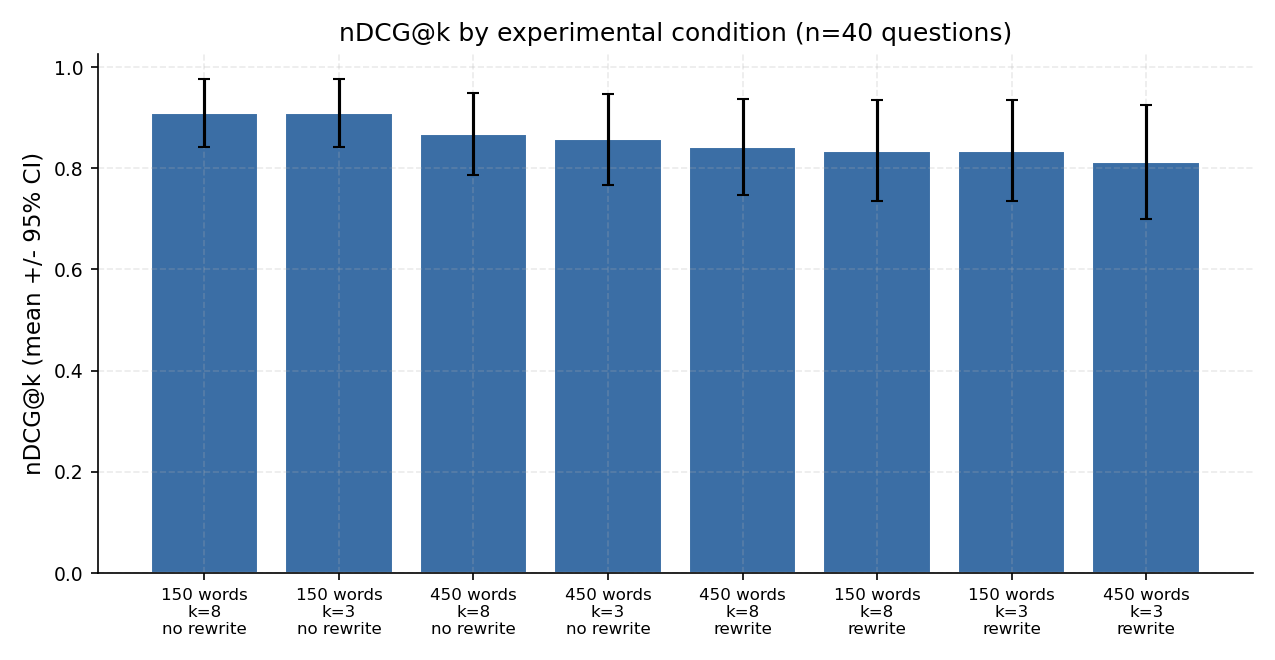

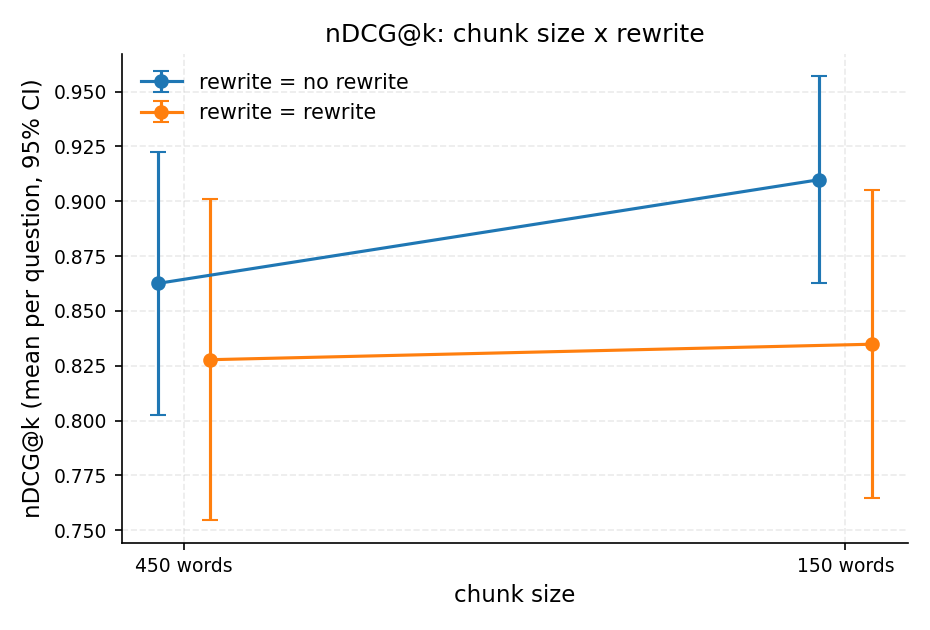

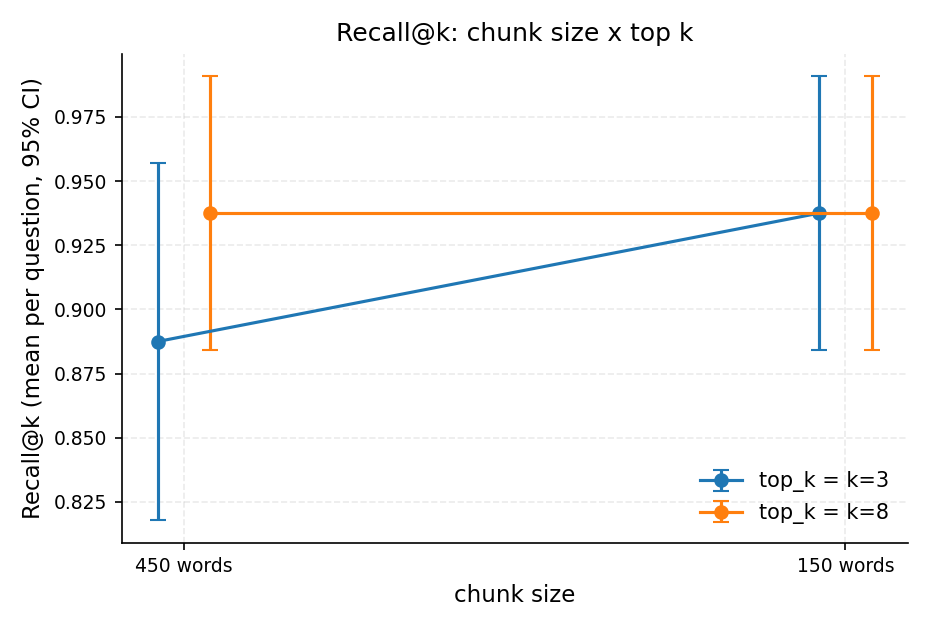

In [5]:
# Interaction plots and condition means
from IPython.display import Image, display
for f in ["retrieval_ndcg_at_k_conditions.png",
          "retrieval_ndcg_at_k_chunk_size_x_rewrite.png",
          "retrieval_recall_at_k_chunk_size_x_top_k.png"]:
    display(Image(filename=os.path.join(FIG, f)))


### What the retrieval results say

Nothing reached p < 0.05. The honest reading:

* **Query rewriting slightly hurt.** No-rewrite beat rewrite by about 6 points
  of recall@k (p = 0.067, Cohen's dz = +0.30). It is not statistically
  significant, but it is the largest effect in the study, and the direction is
  consistent across all three retrieval metrics. My read: the keyword-style
  rewrite strips filler words that TF-IDF was actually using as discriminative
  terms. Rewriting is not free; a bad rewrite is worse than none.
* **Chunk size barely mattered.** 150-word chunks beat 450-word chunks by
  2-3 points (p = 0.35-0.44, dz around +0.13). Small effect, wide CI.
* **Top-k barely mattered.** k=8 vs k=3 differed by 1-2.5 points (p ~ 0.10,
  dz = -0.26). The relevant chunk was usually ranked first anyway.

The bigger lesson is the ceiling effect: a TF-IDF retriever already finds the
source passage for these questions 85-98% of the time, so there is almost no
headroom for any factor to show an effect. If I wanted to separate these
factors, I would need harder questions or a noisier corpus. I am reporting
this instead of re-cutting the data until something is significant.

In [6]:
# Generation: faithfulness judgments on the pre-registered 10-question subset
judged = json.load(open(os.path.join(DATA, "judge.json")))
gen_rows, abst = [], []
for key, g in judged.items():
    is_abs = g["answer"].strip().lower().rstrip(".") == "not stated in the provided context"
    abst.append((g["question_id"], g["chunk_size"], str(g["top_k"]), g["rewrite"], is_abs))
    if not is_abs and g["faithfulness"] is not None:
        gen_rows.append({"question_id": g["question_id"], "chunk_size": g["chunk_size"],
                         "top_k": str(g["top_k"]), "rewrite": g["rewrite"],
                         "faithfulness": g["faithfulness"]})
gen = pd.DataFrame(gen_rows)
abst = pd.DataFrame(abst, columns=["question_id", "chunk_size", "top_k", "rewrite", "abstained"])
print(f"scored answers: {len(gen)}, mean faithfulness: {gen['faithfulness'].mean():.4f}")
print(f"abstentions: {abst['abstained'].sum()} / {len(abst)}")
print("\nfaithfulness by condition:")
print(gen.groupby(["chunk_size", "top_k", "rewrite"])["faithfulness"].mean().round(3).to_string())
print("\nabstentions by condition:")
print(abst.groupby(["chunk_size", "top_k", "rewrite"])["abstained"].sum().to_string())


scored answers: 76, mean faithfulness: 0.9934
abstentions: 4 / 80

faithfulness by condition:
chunk_size  top_k  rewrite
large       3      off        1.000
                   on         1.000
            8      off        1.000
                   on         1.000
small       3      off        1.000
                   on         1.000
            8      off        0.944
                   on         1.000

abstentions by condition:
chunk_size  top_k  rewrite
large       3      off        0
                   on         0
            8      off        0
                   on         0
small       3      off        1
                   on         1
            8      off        1
                   on         1


### What the generation results say

Faithfulness was at the ceiling: 0.993 on average across 76 scored answers,
with 75 of them fully supported. A repeated-measures ANOVA on the 9 questions
with complete data shows nothing (every p = 0.35, driven by a single
below-perfect answer), so I am not going to pretend the ANOVA is informative.
Descriptively, no factor moved faithfulness.

The interesting bits are the exceptions:

* **One genuine slip.** For one question under small chunks / k=8 / no rewrite,
  the generator wrote "monthly migraine days (or monthly headache days)" when
  the passage only said migraine days. The judge caught it: faithfulness 0.5.
  A small overgeneralization, exactly the kind of thing claim-level judging is
  for.
* **Four correct abstentions.** One question (q35) was never retrieved under
  the strict single-chunk relevance rule in any condition. Under small chunks
  the generator correctly said "not stated in the provided context" all four
  times. Under large chunks it answered correctly with full faithfulness,
  because other retrieved chunks also contained the answer. That exposed a
  weakness in my evaluation, not the system: my "single relevant chunk" rule is
  too strict, since the answer can live in more than one chunk. I kept the
  metric as pre-registered and I am flagging this as a limitation.

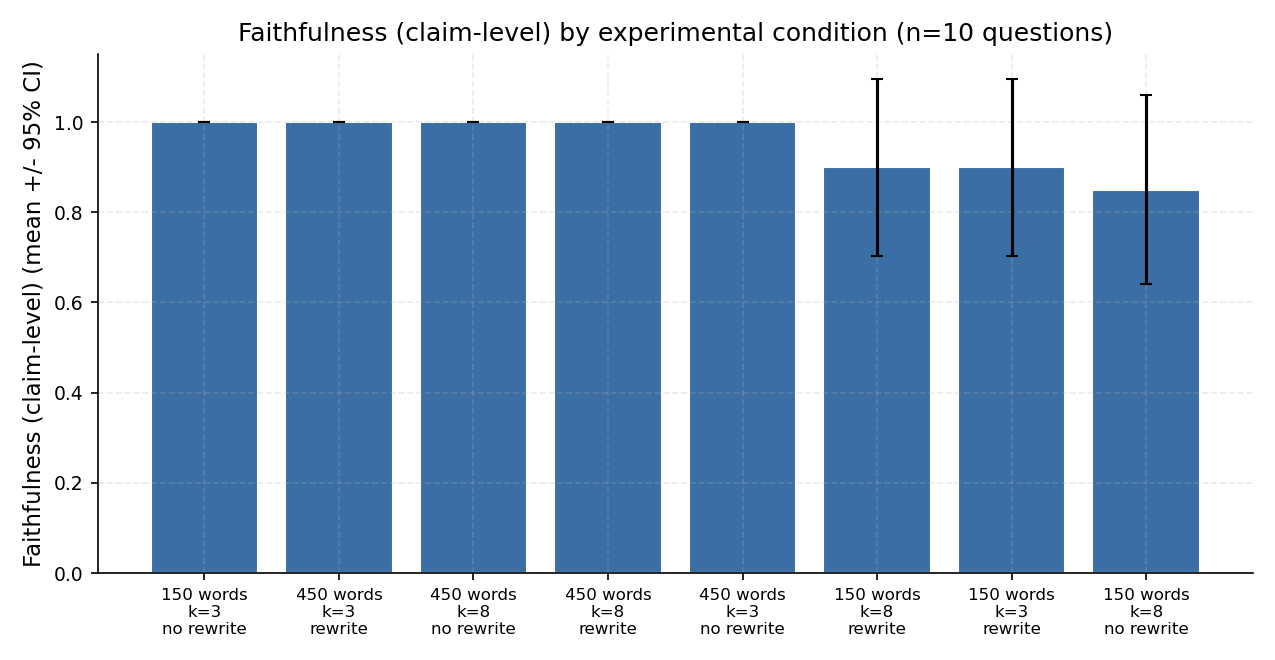

In [7]:
display(Image(filename=os.path.join(FIG, "generation_faithfulness_conditions.png")))

## Takeaway

1. For retrieval on this corpus, none of the three factors mattered much.
   Everything sat between 0.85 and 0.98 recall@k. The largest effect was query
   rewriting *hurting* by about 6 points (p = 0.067, dz = 0.30): my
   keyword-style rewrites dropped terms the TF-IDF retriever needed.
2. Chunk size (150 vs 450 words) moved retrieval by 2-3 points; top-k (3 vs 8)
   by 1-2.5 points. Both small effects with wide confidence intervals.
3. Answer faithfulness was at ceiling (0.993) whenever the generator had the
   right context. The failure mode was not unfaithful writing but missing
   context: the one question whose source chunk was never retrieved got correct
   abstentions under small chunks.
4. The honest takeaway for anyone building RAG: on a clean corpus with
   questions drawn from the documents, a plain TF-IDF retriever plus a
   context-constrained generator is already very good, and fiddling with chunk
   size or top-k buys you almost nothing. Spend the effort on harder retrieval
   problems (noisier corpora, questions that need synthesis across documents)
   and on the relevance judgment, which was the weakest part of my own setup.

## Limitations

* Single relevant chunk per question is too strict (see q35).
* 40 questions is modest; the faithfulness subset is 10. Wide CIs throughout.
* TF-IDF only; no dense retriever comparison.
* The LLM judge can be wrong; two of its outputs needed re-parsing, and it
  ignored the abstention instruction on four answers (handled by excluding
  abstentions from faithfulness, as pre-registered).
* Biomedical abstracts only; results may not transfer to other domains.
* Question drafting, rewriting, generation, and judging all used Gemini
  flash-tier models (3.5-flash-lite, and 3.1-flash-lite for the re-judged
  questions after the former hit its daily quota). Same-model-family
  evaluation is a known bias risk.